# Logistic Regression — Titanic Survival Prediction

## Objectives
- Understand how logistic regression works for binary classification
- Predict whether a passenger survived the Titanic disaster
- Evaluate model using confusion matrix, precision, recall, F1, and ROC-AUC

## Problem
Given passenger information (age, sex, class, fare etc.), predict:
- 1 = Survived
- 0 = Did not survive

In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, accuracy_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
## 1. Load the Data
# Titanic dataset is in seaborn
df = sns.load_dataset('titanic')

print(f'Shape: {df.shape}')
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
## 2. Data Understanding
# Check missing values
print('Missing values:')
print(df.isnull().sum())
print(f'\nSurvival rate: {df["survived"].mean():.1%}')
print(df['survived'].value_counts())

Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Survival rate: 38.4%
survived
0    549
1    342
Name: count, dtype: int64


In [4]:
## 3. Feature Selection and Cleaning
# Keep only useful columns n drop duplicates and high-missing columns
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]

print(f'Shape after column selection: {df.shape}')
df.head()

Shape after column selection: (891, 8)


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [5]:
# Handle missing values
df['age']      = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print('Missing values after fix:')
print(df.isnull().sum())

Missing values after fix:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


In [6]:
# Encode categorical columns
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# One-hot encode embarked, drop_first avoids multicolinearity
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

print(df.shape)
df.head()

(891, 9)


,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [7]:
# Converting boolean columns to integers
df['embarked_Q'] = df['embarked_Q'].astype(int)
df['embarked_S'] = df['embarked_S'].astype(int)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1


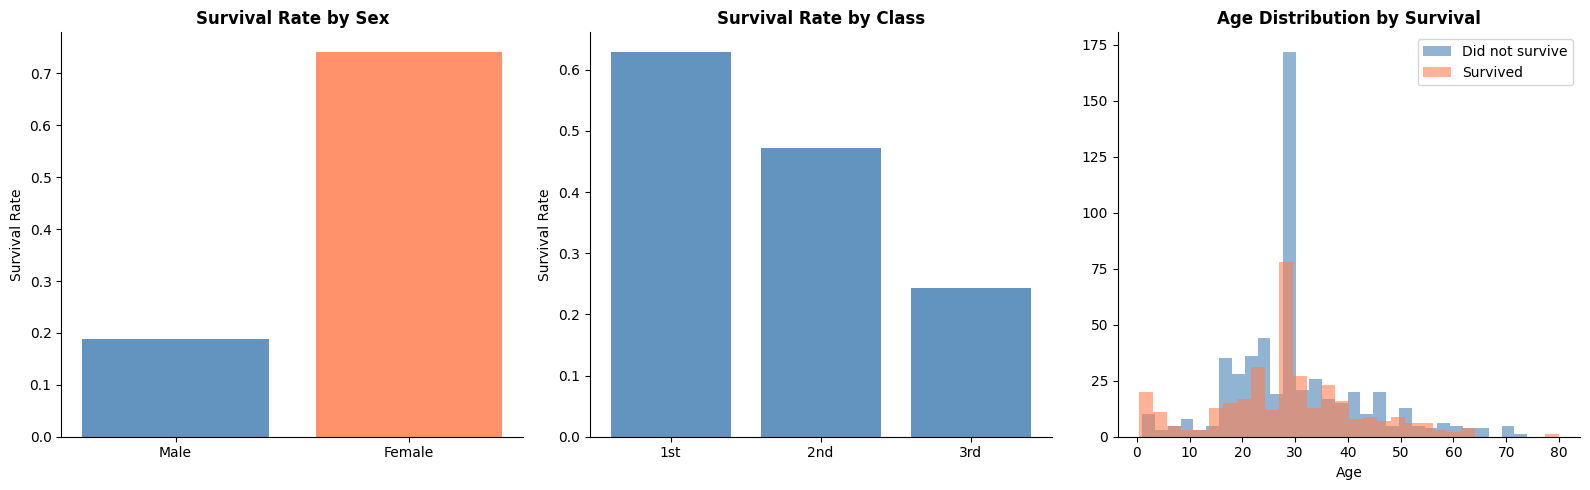

In [8]:
## 4. EDA
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Survival by sex
sex_survival = df.groupby('sex')['survived'].mean()
axes[0].bar(['Male', 'Female'], sex_survival.values, color=['steelblue', 'coral'], alpha=0.85)
axes[0].set_title('Survival Rate by Sex', fontweight='bold')
axes[0].set_ylabel('Survival Rate')

# Survival by class
class_survival = df.groupby('pclass')['survived'].mean()
axes[1].bar(['1st', '2nd', '3rd'], class_survival.values, color='steelblue', alpha=0.85)
axes[1].set_title('Survival Rate by Class', fontweight='bold')
axes[1].set_ylabel('Survival Rate')

# Age distribution by survival
axes[2].hist(df[df['survived']==0]['age'], bins=30, alpha=0.6, color='steelblue', label='Did not survive')
axes[2].hist(df[df['survived']==1]['age'], bins=30, alpha=0.6, color='coral',     label='Survived')
axes[2].set_title('Age Distribution by Survival', fontweight='bold')
axes[2].set_xlabel('Age')
axes[2].legend()

plt.tight_layout()
plt.show()

In [9]:
## 5. Train/Test Split and Scaling
X = df.drop(columns=['survived'])
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')

X_train: (712, 8)
X_test : (179, 8)


In [10]:
## 6. Model Building
# Train logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred       = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')

Accuracy: 0.8101


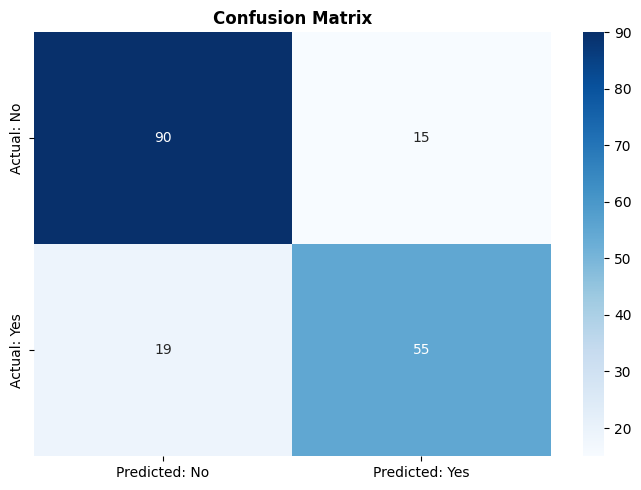

[[90 15]
 [19 55]]


In [11]:
## 7. Evaluation

# 7.1 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No',    'Actual: Yes'])
plt.title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

print(cm)

In [12]:
# 7.2 Clasification Report
print(classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))

                 precision    recall  f1-score   support

Did not survive       0.83      0.86      0.84       105
       Survived       0.79      0.74      0.76        74

       accuracy                           0.81       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179



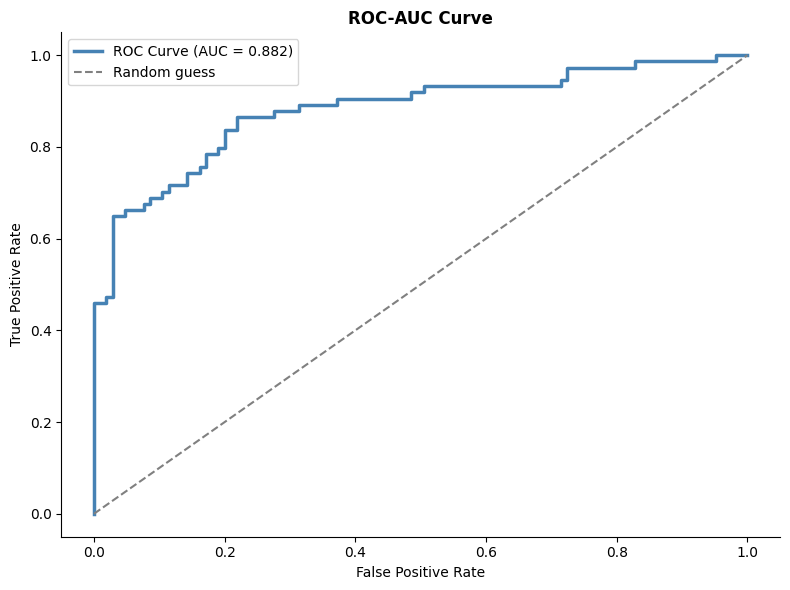

In [13]:
# 7.3 ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

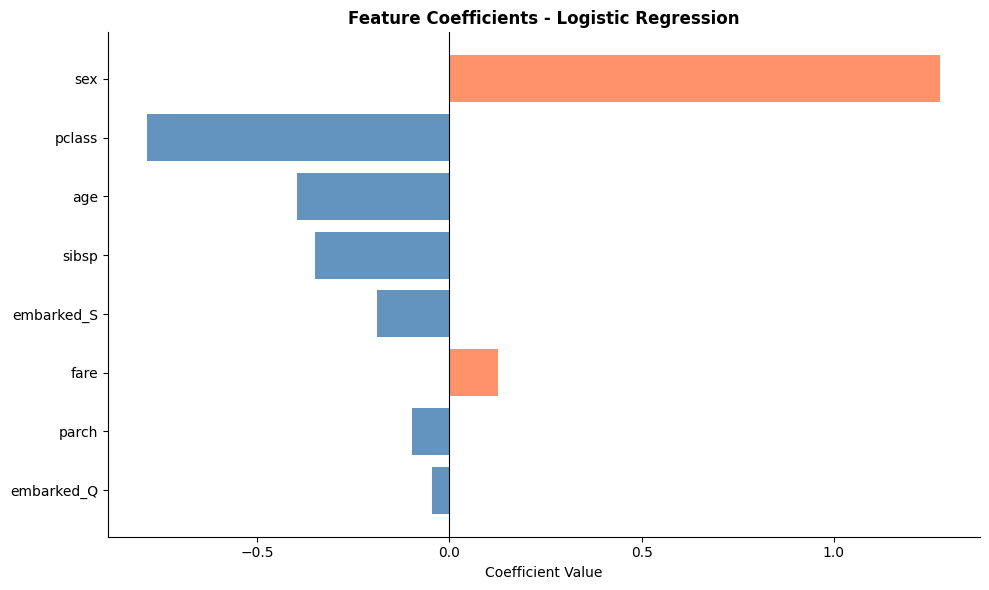

In [14]:
# 7.4 Feature Importance (coeficients)
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=True)

colors = ['coral' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients - Logistic Regression', fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [15]:
## 8. Model Summary
print('=' * 45)
print('       LOGISTIC REGRESSION SUMMARY')
print('=' * 45)
print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_pred_proba):.4f}')
print(f'  Precision : {confusion_matrix(y_test, y_pred)[1,1] / (confusion_matrix(y_test, y_pred)[0,1] + confusion_matrix(y_test, y_pred)[1,1]):.4f}')
print(f'  Recall    : {confusion_matrix(y_test, y_pred)[1,1] / (confusion_matrix(y_test, y_pred)[1,0] + confusion_matrix(y_test, y_pred)[1,1]):.4f}')
print('=' * 45)
print(f'\nTop feature: sex (coef = {model.coef_[0][list(X.columns).index("sex")]:.3f})')
print('Model generalises well as no overfitting signs')

       LOGISTIC REGRESSION SUMMARY
  Accuracy  : 0.8101
  ROC-AUC   : 0.8820
  Precision : 0.7857
  Recall    : 0.7432

Top feature: sex (coef = 1.277)
Model generalises well as no overfitting signs
